## GENeSYS-MOD RES Tool - CANADA (single node, southern subset)

Canada as one node using the 55N-clipped polygon. Onshore PV/wind + rooftop + offshore wind. Uses NALCMS land cover, CPCAD protected areas, Canada EEZ and GEBCO bathymetry.

## General requirements & preparation

This timeseries script uses functions from atlite to generate weather timeseries for GENeSYS-MOD. It uses the ERA5 weather dataset, which is downloaded and transformed locally.
Please be aware that for the entire European dataset, a large amount of system memory is required (at least 24GB of RAM).


To use this script, you need to have the following packages installed:
- numpy
- matplotlib
- seaborn
- pandas / geopandas
- scikit-learn
- cartopy
- xarray
- atlite

In addition, in order to be able to load the ERA5 cutouts, you need an API key from https://cds.climate.copernicus.eu/user/register?destination=%2F%23!%2Fhome

To activate the API key, follow the instructions at https://cds.climate.copernicus.eu/api-how-to

For more information on how to run atlite, please refer to https://atlite.readthedocs.io/en/latest/

In [1]:
from functions import *

In [2]:
onshore_turbine = 'Vestas_V112_3MW'
offshore_turbine = 'Vestas_V164_7MW_offshore'
solar_panel = 'CSi'

# Canada as ONE node, southern subset (polygon clipped at 55N): captures ~all
# population, grid and southern hydro while keeping the cutout smaller.
geo_file = "geodata/iso_regions_canada_south55.geojson"
# Canada EEZ (filtered from the world EEZ v12 to SOVEREIGN1='Canada').
offshore_file = "geodata/eez_canada.geojson"
# GEBCO bathymetry over the Canada box (var 'elevation', coords lat/lon - the
# get_coords bathymetry reader auto-detects these).
bathymetry_file = "geodata/gebco_2026_n56.0_s41.0_w-134.0_e-52.0.nc"

timeframe = "2018"
filename = "canada"
output_dir = create_output_folder(timeframe)

admin = 0
regions = []          # empty = all regions in geo_file (just 'Canada')

cutout_north_west = []
cutout_south_east = []

# --- Run switches (speed / navigation) ----------------------------------
# Skip the full-area capacity-factor timeseries block (PV/wind/heat) while
# iterating on the GIS potentials; set True for a full timeseries export.
generate_full_area_timeseries = False

# GIS availability: True = memory-safe per-region loop; False = single-pass
# (all regions at once). Only one set of cells runs.
run_GIS_analysis_by_region = True

# Availability-map colour: a hex (e.g. '#004664' -> white->navy ramp) or a
# named matplotlib colormap (e.g. 'Greens'). None = default Greens.
map_color = '#004664'


The output folder already exists.


In [3]:
# PV slope/azimuth for utility-scale (ground-mounted) PV.
pv_slope = 36.7
pv_azimuth = 180

# Optimal tilt: if True, utility-scale PV uses a per-coordinate optimal fixed
# tilt (function of latitude) and equator-facing azimuth instead of the single
# pv_slope/pv_azimuth above. Cheap closed-form rule (no per-angle yield search).
pv_optimal_tilt = True

# Rooftop PV is installed differently (roof pitch / mixed orientations), so it
# keeps its own fixed slope/azimuth for the separate pv_rooftop timeseries.
rooftop_pv_slope = 25
rooftop_pv_azimuth = 180

# Usable-site thresholds: minimum developable share of a cutout cell for it
# to count as a usable location for the capacity-factor timeseries. Land is
# lenient (1%); rooftop is the built-up fraction (small everywhere), so it
# needs a higher bar to drop near-empty cells - raise if still too many.
usable_threshold = 0.01
usable_threshold_rooftop = 0.05

In [4]:
# Here, you need to define the horizontal and vertical distances (in degrees) between your coordinates
dx_step = 0.275
dy_step = 0.275

## Region Defitinition & Cutout preparation

In this block, you need to define your coordinates, either by using your own fixed coordinates (by defining custom bounds), or using the automatic .geojson mapping for the country of your choice.

Be aware that the first preparation of the cutout will take significant time!

In [5]:
# Pre-check the expected cutout size BEFORE downloading anything: grid cells,
# hourly time steps and total data points. Uses the same regions/geo_file/resolution
# as get_cutout below, so adjust dx/dy or the region selection if it is too large.
estimate_cutout_size(timeframe, regions=regions, geo_file=geo_file, dx=dx_step, dy=dy_step)

Expected cutout size:
  bounds (lon/lat) : [-134.24, -51.65] x [40.68, 56.00]
  grid             : 300 x 55 = 16,500 cells  (dx=0.275, dy=0.275)
  time steps       : 8,760 hourly  (2018)
  points/variable  : 144,540,000
  total points     : 1,589,940,000  (x11 variables)
  uncompressed     : ~6.36 GB float32 (on-disk .nc is far smaller, compressed)


{'nx': 300,
 'ny': 55,
 'n_cells': 16500,
 'n_time': 8760,
 'points_per_var': 144540000,
 'total_points': 1589940000,
 'raw_gb': 6.35976}

In [6]:
cutout = get_cutout(filename, 
                    timeframe, 
                    regions=regions, 
                    geo_file=geo_file, 
                    dx=dx_step, 
                    dy=dy_step)

cutouts/canada_2018_27_27
Cutout already prepared with required variables; skipping prepare().


Plotting your cutout to ensure that everything is correct!

You can add zoom=True/False to zoom into your selection and use size to set the size of the graph if needed.

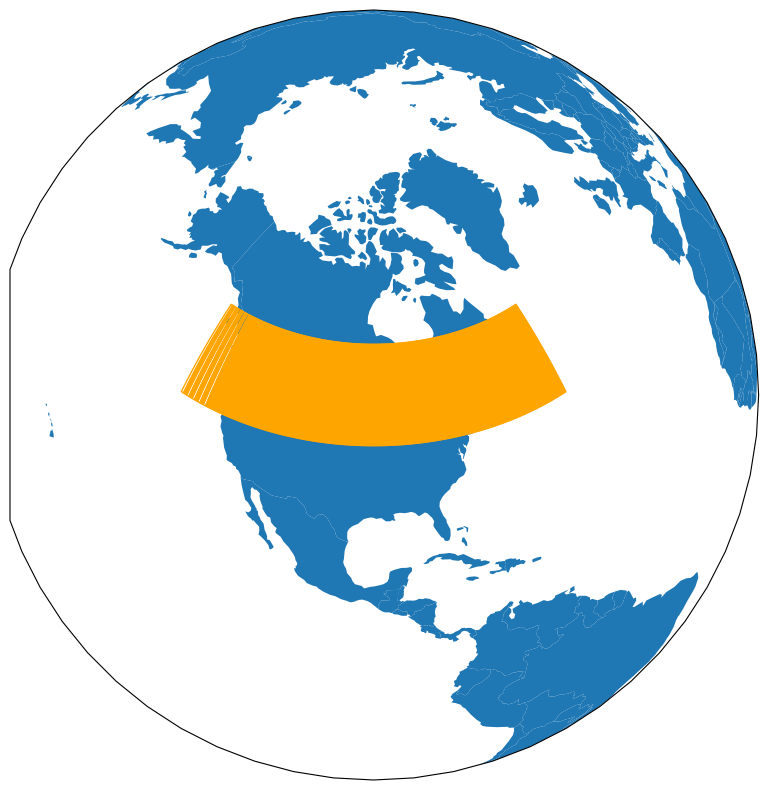

In [7]:
plot_country_map(cutout) # plot_country_map(cutout,zoom=False,size=8)

## General settings and functions

Always run these to create the relevant data entries.

In [8]:
# Offshore enabled: EEZ (eez_canada) + GEBCO depth -> coords_offshore populated.
coords_onshore, coords_offshore = get_coords(cutout, 
                                             regions, 
                                             geo_file, 
                                             admin=admin,
                                             offshore_file=offshore_file,
                                             bathymetry_file=bathymetry_file)

## Functions for timeseries generation

In [9]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    pv_inf, pv_avg, pv_opt = pv_capacity_factors(cutout, 
                                                 coords_onshore, 
                                                 solar_panel,
                                                 pv_slope=pv_slope,
                                                 pv_azimuth=pv_azimuth, 
                                                 optimal_tilt=pv_optimal_tilt,
                                                 timeframe=timeframe, 
                                                 filename=filename,
                                                 write_raw_data=False,
                                                 output_dir=output_dir)

In [10]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    pv_tra = pv_capacity_factors(cutout, 
                                 coords_onshore, 
                                 solar_panel,
                                 tracking= "horizontal",
                                 pv_azimuth=0, #refers to oriantation of the axis in this case
                                 timeframe=timeframe, 
                                 filename=filename,
                                 write_raw_data=False,
                                 output_dir=output_dir)

In [11]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    display(pv_inf.mean())
    display(pv_avg.mean())
    display(pv_opt.mean())

In [12]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    display(pv_tra.mean())

In [13]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    wind_onshore_inf, wind_onshore_avg, wind_onshore_opt = wind_onshore_capacity_factors(cutout, 
                                                                                         coords_onshore, 
                                                                                         onshore_turbine,  
                                                                                         timeframe=timeframe, 
                                                                                         filename=filename,
                                                                                         write_raw_data=False, # determines if you want to have the aggregated outputs per administrative region or the full dataset of each individual coordinate (default: False)
                                                                                         output_dir=output_dir)

In [14]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    display(wind_onshore_inf.mean()) 
    display(wind_onshore_avg.mean()) 
    display(wind_onshore_opt.mean())

In [15]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    wind_offshore_shallow, wind_offshore_transitional, wind_offshore_deep = wind_offshore_capacity_factors(cutout, 
                                                                                                           coords_offshore, 
                                                                                                           offshore_turbine, 
                                                                                                           timeframe=timeframe,
                                                                                                           filename=filename,
                                                                                                           write_raw_data=False, # determines if you want to have the aggregated outputs per administrative region or the full dataset of each individual coordinate (default: False)
                                                                                                           output_dir=output_dir)

In [16]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    display(wind_offshore_shallow.mean())
    display(wind_offshore_transitional.mean())
    display(wind_offshore_deep.mean())

In [17]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    df_heatpump_ground_cop, df_cooling, df_heating, df_heatpump_cop = temperature_timeseries(cutout,
                                                                                            coords_onshore,
                                                                                            timeframe=timeframe,
                                                                                            filename=filename,
                                                                                            write_raw_data=False, # determines if you want to have the aggregated outputs per administrative region or the full dataset of each individual coordinate (default: False)
                                                                                            output_dir=output_dir)

In [18]:
# Controlled by 'generate_full_area_timeseries' switch (set in the config cell).
if generate_full_area_timeseries:
    display(df_heatpump_ground_cop.mean())
    display(df_heatpump_cop.mean())
    display(df_cooling.mean())
    display(df_heating.mean())

# GIS-based renewable energy potentials

##### This part is still somewhat experimental. It uses functionality from the Atlite package to calculate available capcities for utility-scale PV, onshore wind, and rooftop PV installations.
##### It uses the information from the timeseries part to compute the shapefiles, the only thing that needs to be provided is the excluder zones (e.g. WDPA for protected areas). CORINE is provided for land cover in Europe, anything else would need to be separately downloaded.

In [19]:
# Region-agnostic: use the SAME region polygons as the timeseries (onshore),
# not the country/NUTS workflow. Returns region shapes + names.
shapes, regions_name_en = get_region_shapes(geo_file, regions)
#shapes, regions_name_en = get_region_shapes(geo_file, ['California'])

In [20]:
# --- Exclusion layers (CANADA) ---------------------------------------------
# Region-agnostic builders; only the paths/codes below are Canada-specific.
#
# Land cover: NALCMS 2020 v2 30 m (North-America-wide, 19-class). Embeds a
# Canada Albers CRS (no EPSG code) which the builder reads automatically, so
# LANDCOVER_CRS stays None. uint8, nodata 255 (handled).
LANDCOVER = "geodata/CAN_NALCMS_landcover_2020v2_30m.tif"
LANDCOVER_CRS = None

# NALCMS 2020 legend: 1-6 forest, 7-8 shrubland, 9-10 grassland, 11-13 polar
# lichen/moss/barren, 14 wetland, 15 cropland, 16 barren, 17 urban, 18 water,
# 19 snow/ice; 0 = outside/no-data. STRICT: exclude forests, wetland, cropland,
# urban, water, snow/ice, polar lichen/moss and 0. Keep shrubland(7,8),
# grassland(9,10), barren(16).
nalcms_exclude = [0, 1, 2, 3, 4, 5, 6, 11, 12, 13, 14, 15, 17, 18, 19]

# Protected areas: CPCAD (Canadian Protected & Conserved Areas DB) File GDB.
# Layer holds 22k polygons (Canada Albers). Excluding all of them = strict.
# To keep only IUCN-strict classes set PROTECTED_QUERY (verify the value strings
# in IUCN_CAT first), e.g. "IUCN_CAT in ['Ia','Ib','II','III','IV']".
PROTECTED       = "geodata/ProtectedConservedArea_2025.gdb"
PROTECTED_LAYER = "ProtectedConservedArea_2025"
PROTECTED_QUERY = None

excluder = make_land_excluder(
    LANDCOVER, nalcms_exclude, raster_crs=LANDCOVER_CRS,
    protected_files=PROTECTED, protected_layer=PROTECTED_LAYER,
    protected_query=PROTECTED_QUERY,
)

# Rooftop proxy: NALCMS urban/built-up class only (17).
cities = make_rooftop_excluder(LANDCOVER, [17], raster_crs=LANDCOVER_CRS)

# --- Offshore exclusion -----------------------------------------------------
# Combined no-build mask (geodata/offshore_exclude_canada.geojson, built once):
#   * CPCAD marine protected areas (BIOME=M)
#   * Hudson Bay + James Bay + Ungava Bay (enclosed, ice-bound, no grid)
#   * everything north of 60N (Arctic). Depth alone keeps these; this drops them.
OFFSHORE_EXCLUDE_FILES = "geodata/offshore_exclude_canada.geojson"
OFFSHORE_EXCLUDE_LAYER = None
OFFSHORE_EXCLUDE_QUERY = None

In [21]:
pv_cap_per_sqkm = 100                   # MW
pv_percent_land_available = 0.03        # % of suitable area
wind_cap_per_sqkm = 27                  # MW
wind_percent_land_available = 0.03      # % of suitable area
rooftop_cap_per_sqkm = 100              # MW
rooftop_percent_area_available = 0.05   # installable share of built-up area

## Compute area availability (single pass, memory intensive)

This will calculate available surface areas for onshore, offshore, and rooftops using the excluders specified. Memory-intensive, since it calculates it all at once. See below for per-region loop version.

In [22]:
# Controlled by '(not run_GIS_analysis_by_region)' switch (set in the config cell).
if (not run_GIS_analysis_by_region):
    AvailabilityMatrix = calculate_and_plot_available_area(admin,cutout,shapes,regions_name_en,excluder)

In [23]:
# Controlled by '(not run_GIS_analysis_by_region)' switch (set in the config cell).
if (not run_GIS_analysis_by_region):
    AvailabilityMatrix_Rooftop = calculate_and_plot_available_rooftops(admin,cutout,shapes,regions_name_en,cities)

In [24]:
# Controlled by '(not run_GIS_analysis_by_region)' switch (set in the config cell).
if (not run_GIS_analysis_by_region):
    output_df = calculate_capacity_potentials(cutout,coords_onshore,AvailabilityMatrix,AvailabilityMatrix_Rooftop,pv_cap_per_sqkm,pv_percent_land_available,wind_cap_per_sqkm,wind_percent_land_available,rooftop_cap_per_sqkm,rooftop_percent_area_available)

In [25]:
# Controlled by '(not run_GIS_analysis_by_region)' switch (set in the config cell).
if (not run_GIS_analysis_by_region):
    # here is the resulting DataFrame containing all the potentials and areas that have been calculated
    output_df

## Compute area availability (Memory-safe all-region run)

The cells above process every region at once, which rasterizes the land-cover map over the full extent and can exhaust RAM at 30 m. 
`calculate_potentials_per_region` processes one region at a time (bounded raster window), writes a per-region CSV plus a combined CSV, 
and returns one stitched availability map across all regions. Reuses the same `excluder`/`cities` defined above.

Processing region: Canada
offshore exclusion: dropped 333 of 1658 cells


,region,Area [km²],Suitable Area PV [km²],Suitable Area Wind [km²],Suitable Area Rooftops [km²],PV Capacity [GW],Rooftop Capacity [GW],Wind Capacity [GW]
0,Canada,4.119818e+06,14560.034758,14560.034758,2928.461586,1456.003476,292.846159,393.120938


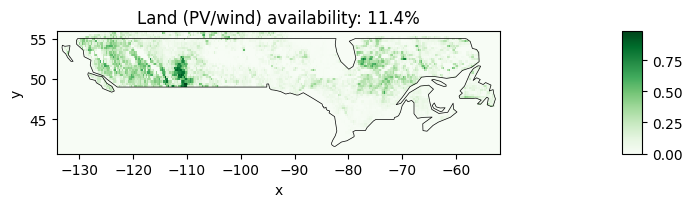

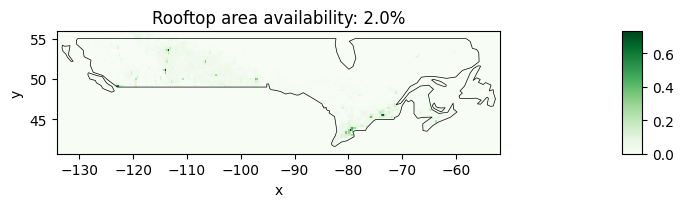

In [13]:
# Controlled by 'run_GIS_analysis_by_region' switch (set in the config cell).
if run_GIS_analysis_by_region:
    # Memory-safe: process every region one at a time. Saves per-region + combined
    # CSVs, returns the stitched availability map + usable coords (land/rooftop/offshore)
    # for the usable-site timeseries below. Passing pv_solar_panel adds a site-quality
    # 'category' (inf/avg/opt) column to the usable-coords CSVs. regions=[] = all.
    combined_potentials, stitched_land, stitched_rooftop, coords_onshore_usable, coords_rooftop_usable, coords_offshore_usable = calculate_potentials_per_region(
        cutout, geo_file, coords_onshore,
        excluder=excluder, cities=cities,
        regions=regions,
        coords_offshore=coords_offshore,
        usable_threshold=usable_threshold, usable_threshold_rooftop=usable_threshold_rooftop,
        offshore_exclude_files=OFFSHORE_EXCLUDE_FILES,
        offshore_exclude_layer=OFFSHORE_EXCLUDE_LAYER,
        offshore_exclude_query=OFFSHORE_EXCLUDE_QUERY,
        pv_cap_per_sqkm=pv_cap_per_sqkm, pv_percent_land_available=pv_percent_land_available,
        wind_cap_per_sqkm=wind_cap_per_sqkm, wind_percent_land_available=wind_percent_land_available,
        rooftop_cap_per_sqkm=rooftop_cap_per_sqkm, rooftop_percent_area_available=rooftop_percent_area_available,
        pv_solar_panel=solar_panel, pv_slope=pv_slope, pv_azimuth=pv_azimuth,
        optimal_tilt=pv_optimal_tilt, rooftop_pv_slope=rooftop_pv_slope, rooftop_pv_azimuth=rooftop_pv_azimuth,
        output_dir=output_dir, filename=filename, color=map_color,
    )
    combined_potentials

### Offshore wind potential

Reuses the EEZ-clipped, depth-classified offshore cells from `get_coords` (so only actual offshore zones are counted). Capacity density and available share can be set per depth class (shallow/transitional = fixed-bottom, deep = floating).

In [26]:
# Offshore wind potential per region and depth class. Uses coords_offshore from
# the timeseries step (EEZ + depth). Densities/availability can be a scalar or a
# dict keyed by depth class. Floating (deep) gets a lower available share here.
offshore_cap_per_sqkm = 5            # MW/km2
offshore_percent_available = {"shallow": 0.10, "transitional": 0.10, "deep": 0.05}

offshore_df = calculate_offshore_potentials(
    cutout, coords_offshore,
    offshore_cap_per_sqkm=offshore_cap_per_sqkm,
    offshore_percent_available=offshore_percent_available,
)
offshore_df

,region,depth_class,Area [km²],Suitable Area Offshore [km²],Offshore Wind Capacity [GW]
0,Canada,shallow,98160.281605,9816.028160,49.080141
1,Canada,transitional,112545.721068,11254.572107,56.272861
2,Canada,deep,801694.817526,40084.740876,200.423704


In [ ]:
# Offshore potential on USABLE sites only (depth + marine-protected-area exclusion),
# for comparison with the theoretical (depth-only) table above. Writes its own CSV.
if 'coords_offshore_usable' not in dir() or coords_offshore_usable is None:
    coords_offshore_usable = usable_offshore_coords(coords_offshore,
        exclude_files=OFFSHORE_EXCLUDE_FILES, exclude_layer=OFFSHORE_EXCLUDE_LAYER,
        exclude_query=OFFSHORE_EXCLUDE_QUERY)

offshore_df_usable = calculate_offshore_potentials(
    cutout, coords_offshore_usable,
    offshore_cap_per_sqkm=offshore_cap_per_sqkm,
    offshore_percent_available=offshore_percent_available,
)
offshore_df_usable.to_csv(os.path.join(output_dir, f"{filename}_potentials_offshore_usable.csv"), index=False)
offshore_df_usable

In [29]:
# Standalone offshore export: pivot offshore_df to one row per region with depth-
# class columns + total, and write to CSV. Only needs offshore_df (run the cell
# above first) - does NOT require the per-region combined run.
_off_wide = offshore_df.pivot_table(index="region", columns="depth_class",
                                    values="Offshore Wind Capacity [GW]",
                                    aggfunc="sum", observed=True)
_off_wide.columns = [f"Offshore Wind {c} [GW]" for c in _off_wide.columns]
_off_wide["Offshore Wind Total [GW]"] = _off_wide.sum(axis=1)
_off_wide = _off_wide.reset_index()
_off_wide.to_csv(os.path.join(output_dir, f"{filename}_potentials_offshore.csv"), index=False)
_off_wide

,region,Offshore Wind shallow [GW],Offshore Wind transitional [GW],Offshore Wind deep [GW],Offshore Wind Total [GW]
0,Canada,49.080141,56.272861,200.423704,305.776706


offshore exclusion: dropped 333 of 1658 cells
usable offshore cells: 1325 of 2502


<Axes: title={'center': 'Usable offshore cells by depth_class'}>

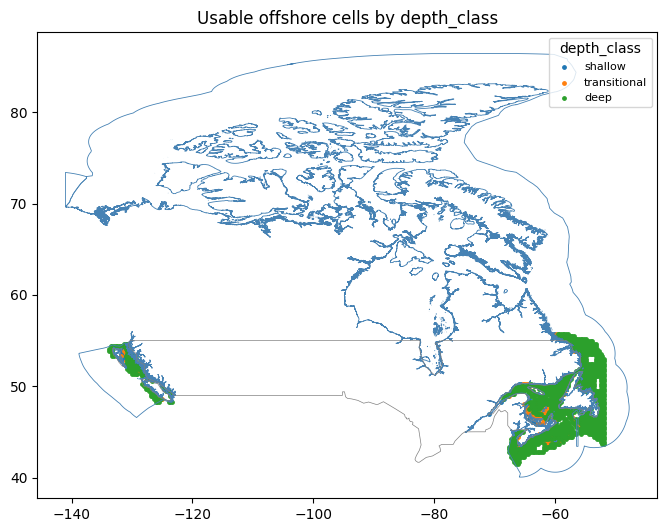

In [28]:
# Usable offshore sites across ALL regions come from the loop above
# (coords_offshore_usable), already filtered by depth AND marine protected areas.
if 'coords_offshore_usable' not in dir() or coords_offshore_usable is None:
    coords_offshore_usable = usable_offshore_coords(coords_offshore,
        exclude_files=OFFSHORE_EXCLUDE_FILES, exclude_layer=OFFSHORE_EXCLUDE_LAYER,
        exclude_query=OFFSHORE_EXCLUDE_QUERY)
print(f"usable offshore cells: {len(coords_offshore_usable)} of {len(coords_offshore)}")

# Offshore wind capacity factors on usable sites only (shallow/transitional/deep):
wind_off_shallow_u, wind_off_trans_u, wind_off_deep_u = wind_offshore_capacity_factors(
    cutout, coords_offshore_usable, offshore_turbine,
    timeframe=timeframe, filename=filename+"_usable",
    write_raw_data=False, output_dir=output_dir)

# Map of the usable offshore cells, coloured by depth class:
plot_offshore_map(coords_offshore_usable, shapes=shapes, offshore_file=offshore_file, color_by="depth_class")

### Capacity-factor timeseries on usable sites only

Restrict the RES timeseries to cells that survive the exclusion layers. 
`usable_onshore_coords` keeps cutout cells whose availability > threshold (from the 
availability matrix); feed those into the normal PV / onshore-wind functions, which 
still split into opt/avg/inf. `usable_offshore_coords` keeps buildable offshore cells 
(depth within limits) for the offshore-wind timeseries.

In [18]:
# Usable onshore sites across ALL regions come from the memory-safe loop above
# (coords_onshore_usable). For a quick single-region test instead, use:
#   coords_onshore_usable = usable_onshore_coords(AvailabilityMatrix, coords_onshore)
print(f"usable onshore cells: {len(coords_onshore_usable)} of {len(coords_onshore)}")
print(f"usable rooftop cells: {len(coords_rooftop_usable)} of {len(coords_onshore)}")

# Utility-scale PV on usable land (per-cell optimal tilt if pv_optimal_tilt):
pv_inf_u, pv_avg_u, pv_opt_u = pv_capacity_factors(cutout, coords_onshore_usable, solar_panel,
                                                   pv_slope=pv_slope, pv_azimuth=pv_azimuth,
                                                   optimal_tilt=pv_optimal_tilt,
                                                   timeframe=timeframe, filename=filename+"_usable",
                                                   write_raw_data=False, output_dir=output_dir)

# Rooftop PV: separate category, only rooftop-available cells, own fixed slope/azimuth
# (roofs dictate orientation, so no optimal-tilt here). Label "pv_rooftop".
pv_roof_inf, pv_roof_avg, pv_roof_opt = pv_capacity_factors(cutout, coords_rooftop_usable, solar_panel,
                                                            pv_slope=rooftop_pv_slope, pv_azimuth=rooftop_pv_azimuth,
                                                            tech_label="pv_rooftop",
                                                            timeframe=timeframe, filename=filename+"_usable",
                                                            write_raw_data=False, output_dir=output_dir)

# Onshore wind capacity factors on usable land:
wind_inf_u, wind_avg_u, wind_opt_u = wind_onshore_capacity_factors(cutout, coords_onshore_usable, onshore_turbine,
                                                                   timeframe=timeframe, filename=filename+"_usable",
                                                                   write_raw_data=False, output_dir=output_dir)

usable onshore cells: 5775 of 6979
usable rooftop cells: 376 of 6979


usable offshore cells: 1325 of 2502


<Axes: title={'center': 'Usable offshore cells by depth_class'}>

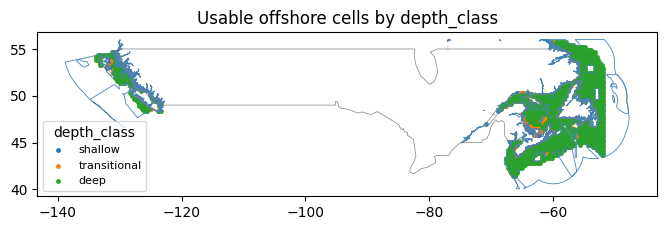

In [19]:
# Usable offshore sites across ALL regions come from the loop above
# (coords_offshore_usable), already filtered by depth AND marine protected areas.
if 'coords_offshore_usable' not in dir() or coords_offshore_usable is None:
    coords_offshore_usable = usable_offshore_coords(coords_offshore,
        exclude_files=OFFSHORE_EXCLUDE_FILES, exclude_layer=OFFSHORE_EXCLUDE_LAYER,
        exclude_query=OFFSHORE_EXCLUDE_QUERY)
print(f"usable offshore cells: {len(coords_offshore_usable)} of {len(coords_offshore)}")

# Offshore wind capacity factors on usable sites only (shallow/transitional/deep):
wind_off_shallow_u, wind_off_trans_u, wind_off_deep_u = wind_offshore_capacity_factors(
    cutout, coords_offshore_usable, offshore_turbine,
    timeframe=timeframe, filename=filename+"_usable",
    write_raw_data=False, output_dir=output_dir)

# Map of the usable offshore cells, coloured by depth class:
# Map uses the cleaned EEZ outline (Hudson Bay/Arctic removed) for a tidy background.
plot_offshore_map(coords_offshore_usable, shapes=shapes,
                  offshore_file="geodata/eez_canada_clean.geojson", color_by="depth_class")

## Plot usable sites

Maps of the developable cells per technology, colour-coded by site-quality class (inf / avg / opt) for onshore and rooftop, and by depth class for offshore. The `category` column is written into the usable-coords CSVs by the memory-safe potentials cell.

**Sensitivity:** the minimum developable share per cell is `usable_threshold` (and `usable_threshold_rooftop`) in the parameters cell. Raise it (e.g. 0.02, 0.03) to drop low-availability cells, then re-run the potentials + this cell.

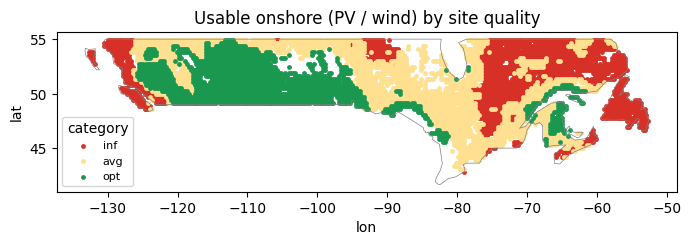

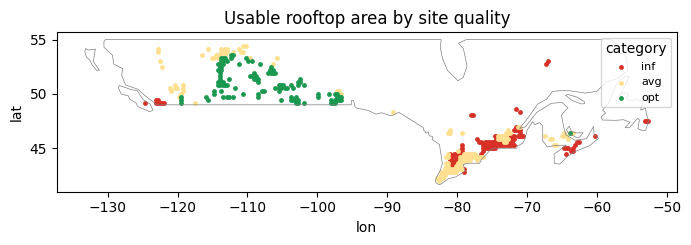

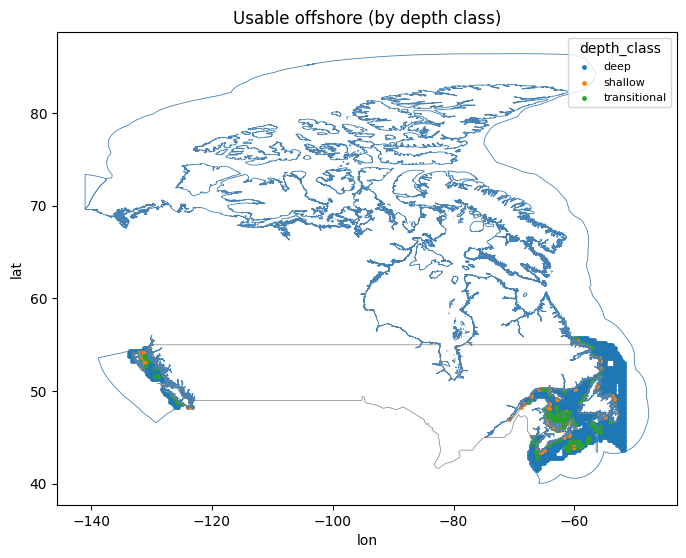

In [20]:
# Maps of usable sites per technology, colour-coded. Onshore/rooftop use the
# site-quality 'category' column (inf/avg/opt) now stored in the usable-coords;
# offshore uses depth class. Guarded so missing/empty layers are skipped.
_region_shapes = shapes if 'shapes' in dir() else None

if 'coords_onshore_usable' in dir() and coords_onshore_usable is not None and len(coords_onshore_usable):
    plot_usable_coords(coords_onshore_usable, shapes=_region_shapes,
                       color_by='category', title='Usable onshore (PV / wind) by site quality')

if 'coords_rooftop_usable' in dir() and coords_rooftop_usable is not None and len(coords_rooftop_usable):
    plot_usable_coords(coords_rooftop_usable, shapes=_region_shapes,
                       color_by='category', title='Usable rooftop area by site quality')

if 'coords_offshore_usable' in dir() and coords_offshore_usable is not None and len(coords_offshore_usable):
    plot_usable_coords(coords_offshore_usable, shapes=_region_shapes,
                       boundary_file=offshore_file, color_by='depth_class',
                       title='Usable offshore (by depth class)')